In [469]:
import numpy as np
import pandas as pd
from math import exp
from matplotlib import pyplot, animation
import matplotlib.pyplot as plt
from numpy import sqrt

In [470]:
def F(u):
    return c*u

In [471]:
def u_0(x):
    if x <= 1 and x >=-1:
        return 5
    else :
        return 0

In [472]:
def U_ex(x, t):
    return u_0(x-c*t)

In [473]:
def vanLeer(r):
    if r==1e6:
        return 2
    else:
        return (r+abs(r))/(1+abs(r))

In [474]:
def superBee(r):
    return max(0, min(2*r, 1), min(r, 2))

In [475]:
def minmod2(a):
    return max(0,min(1,a))

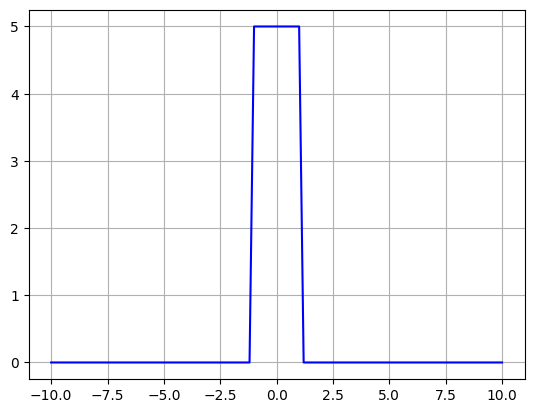

In [476]:
a = -10
b = 10
c = 2
N = 101
dx = (b-a)/(N-1)
x = np.linspace(a,b,N)

Un = np.zeros(N)
for i in range(N):
    Un[i] = u_0(x[i])

UnM = np.zeros(N)
for i in range(N):
    UnM[i] = u_0(x[i])



UnS = np.zeros(N)
for i in range(N):
    UnS[i] = u_0(x[i])


UnV = np.zeros(N)
for i in range(N):
    UnV[i] = u_0(x[i])


plt.plot(x,UnV,'-b')
plt.grid()

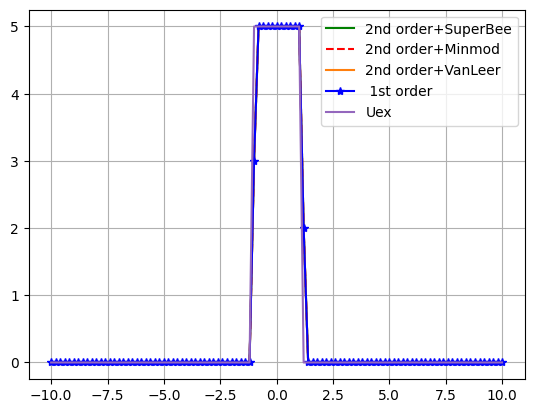

0.04000000000000001


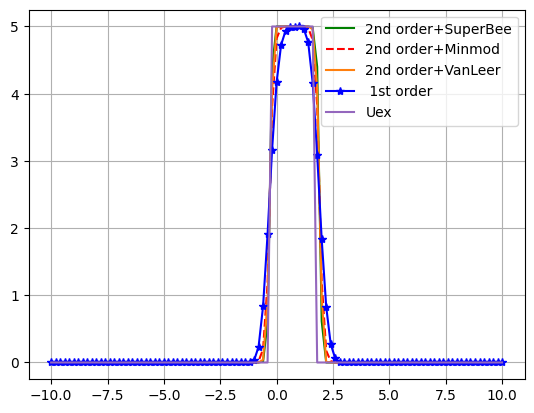

0.40000000000000013


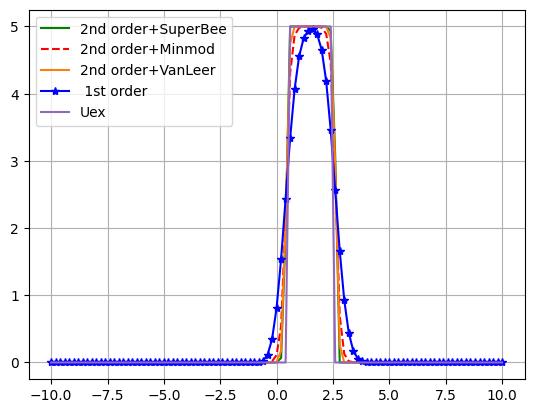

0.7600000000000005


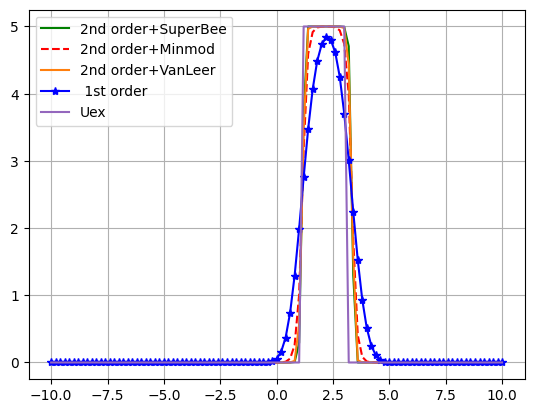

1.1200000000000008


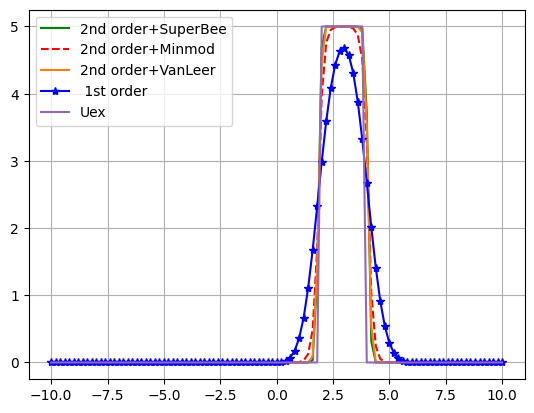

1.480000000000001


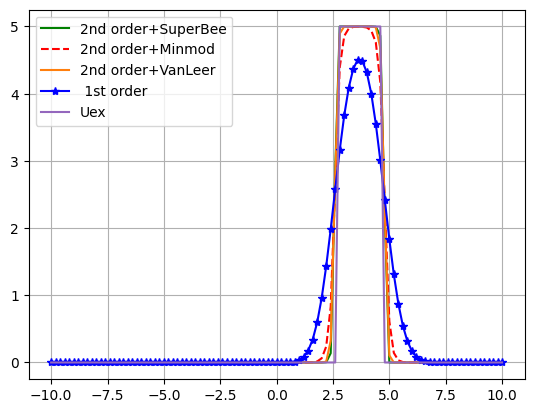

1.8400000000000014


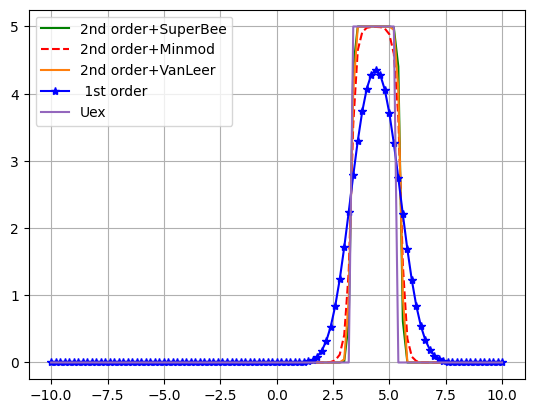

2.2000000000000015


In [477]:
cfl = 0.4
dt = (cfl*dx)/abs(c)
temps = 0
T_final = 2.5
Unp1S = np.zeros(N)
Unp1 = np.zeros(N)
Unp1M= np.zeros(N)
Unp1V= np.zeros(N)
lam = dt/dx
seuil = 1e-6

j=0


while(temps < T_final):
    for i in range(1,N-2):
        r = np.zeros(N)

        if abs(UnV[i+1]-UnV[i])< seuil :
            r[i] = 0
        else :
            r[i] = (UnV[i]-UnV[i-1])/(UnV[i+1]-UnV[i])
        if abs(UnV[i]-UnV[i-1])< seuil :
            r[i-1] = 0
        else :
            r[i-1] = (UnV[i-1]-UnV[i-2])/(UnV[i]-UnV[i-1])
        if abs(UnV[i+2]-UnV[i+1])< seuil :
            r[i+1] = 0
        else :
            r[i+1] = (UnV[i+1]-UnV[i])/(UnV[i+2]-UnV[i+1])



        UrpV = UnV[i+1] - vanLeer(r[i+1])*(UnV[i+2]- UnV[i+1])/2
        UlpV = UnV[i] + vanLeer(r[i])*(UnV[i+1]- UnV[i])/2
        UrmV = UnV[i] - vanLeer(r[i])* (UnV[i+1]- UnV[i])/2
        UlmV = UnV[i-1]+ vanLeer(r[i-1])*(UnV[i]- UnV[i-1])/2

        FgV = 0.5*(F(UlmV) + F(UrmV)) - 0.5*abs(c)*(UrmV-UlmV)
        FdV = 0.5*(F(UlpV) + F(UrpV)) - 0.5*abs(c)*(UrpV-UlpV)
        Unp1V[i] = UnV[i] - lam*(FdV-FgV)

    for i in range(1,N-2):

        r1 = np.zeros(N)

        if abs(UnM[i+1]-UnM[i])< seuil :
            r1[i] = 0
        else :
            r1[i] = (UnM[i]-UnM[i-1])/(UnM[i+1]-UnM[i])
        if abs(UnM[i]-UnM[i-1])< seuil :
            r1[i-1] = 0
        else :
            r1[i-1] = (UnM[i-1]-UnM[i-2])/(UnM[i]-UnM[i-1])
        if abs(UnM[i+2]-UnM[i+1])< seuil :
            r1[i+1] = 0
        else :
            r1[i+1] = (UnM[i+1]-UnM[i])/(UnM[i+2]-UnM[i+1])



        UrpM = UnM[i+1] - minmod2(r1[i+1])*(UnM[i+2]- UnM[i+1])/2
        UlpM = UnM[i] + minmod2(r1[i])*(UnM[i+1]- UnM[i])/2
        UrmM = UnM[i] - minmod2(r1[i])* (UnM[i+1]- UnM[i])/2
        UlmM = UnM[i-1]+ minmod2(r1[i-1])*(UnM[i]- UnM[i-1])/2

        FgM = 0.5*(F(UlmM) + F(UrmM)) - 0.5*abs(c)*(UrmM-UlmM)
        FdM = 0.5*(F(UlpM) + F(UrpM)) - 0.5*abs(c)*(UrpM-UlpM)
        Unp1M[i] = UnM[i] - lam*(FdM-FgM)


    for i in range(1,N-2):
        r2 = np.zeros(N)

        if abs(UnS[i+1]-UnS[i])< seuil :
            r2[i] = 0
        else :
            r2[i] = (UnS[i]-UnS[i-1])/(UnS[i+1]-UnS[i])
        if abs(UnS[i]-UnS[i-1])< seuil :
            r2[i-1] = 0
        else :
            r2[i-1] = (UnS[i-1]-UnS[i-2])/(UnS[i]-UnS[i-1])
        if abs(UnS[i+2]-UnS[i+1])< seuil :
            r2[i+1] = 0
        else :
            r2[i+1] = (UnS[i+1]-UnS[i])/(UnS[i+2]-UnS[i+1])



        UrpS = UnS[i+1] - superBee(r2[i+1])*(UnS[i+2]- UnS[i+1])/2
        UlpS = UnS[i] + superBee(r2[i])*(UnS[i+1]- UnS[i])/2
        UrmS = UnS[i] - superBee(r2[i])* (UnS[i+1]- UnS[i])/2
        UlmS = UnS[i-1]+ superBee(r2[i-1])*(UnS[i]- UnS[i-1])/2

        FgS = 0.5*(F(UlmS) + F(UrmS)) - 0.5*abs(c)*(UrmS-UlmS)
        FdS = 0.5*(F(UlpS) + F(UrpS)) - 0.5*abs(c)*(UrpS-UlpS)
        Unp1S[i] = UnS[i] - lam*(FdS-FgS)

    for i in range(1,N-1):
        Fg = (0.5)*(F(Un[i-1]) + F(Un[i])) - 0.5*abs(c)*(Un[i]-Un[i-1])
        Fd = 0.5*(F(Un[i]) + F(Un[i+1])) - 0.5*abs(c)*(Un[i+1]-Un[i])
        Unp1[i] = Un[i] - lam*(Fd-Fg)

    Unp1S[0]= Unp1S[1]
    Unp1S[N-1]= Unp1S[N-2]
    UnS = Unp1S.copy()

    Unp1M[0]= Unp1M[1]
    Unp1M[N-1]= Unp1M[N-2]
    UnM = Unp1M.copy()

    Unp1V[0]= Unp1V[1]
    Unp1V[N-1]= Unp1V[N-2]
    UnV = Unp1V.copy()

    Unp1[0]= Unp1[1]
    Unp1[N-1]= Unp1[N-2]
    Un = Unp1.copy()



    Uex = [U_ex(i,temps) for i in x]
    temps = temps + dt

    if j%9==0:
        plt.plot(x,UnS,'g-', label='2nd order+SuperBee')
        plt.plot(x,UnM,'r--', label='2nd order+Minmod')
        plt.plot(x,UnV,color='tab:orange', label='2nd order+VanLeer')
        plt.plot(x,Un,'b-*', label=' 1st order ')
        plt.grid()
        plt.plot(x,Uex,color='tab:purple', label='Uex')
        plt.legend()
        #plt.ylim(-5, 10)
        plt.pause(0.1)
        print(temps)
    j+=1